# 3D Sphere Dataset

In [4]:
%load_ext autoreload
%autoreload 2

import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'


import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
from IPython.display import clear_output
from jaxtyping import ArrayLike, Float

from datasets.lagrangian_potentials import Sphere_Potential
from method.dynamics import LagrangianFlow
from method.hota import HOTA
from networks.mlp import MLPwTime
from utils.metrics import sinkhorn_loss

GLOBAL_KEY = jax.random.key(42)
LOG_DIR = f"{os.environ['PROJECT_DIR']}/figures"
if not os.path.exists(LOG_DIR):
    os.mkdir(LOG_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utils

In [5]:
def draw_trajs_3d(trajs: Float[ArrayLike, 'timestep point dim=2'], ax=None):
    colors = sns.color_palette("pastel", trajs.shape[1])
    
    for point in range(trajs.shape[1]):
        for t in range(1, trajs.shape[0]):
            ax.plot([trajs[t-1, point, 0], trajs[t, point, 0]],
                    [trajs[t-1, point, 1], trajs[t, point, 1]],
                    [trajs[t-1, point, 2], trajs[t, point, 2]],
                    color=colors[point], linestyle="-", linewidth=1, marker='o', alpha=1.0, markersize=1, zorder=0)
    return ax

## 3D Sphere Dataset

100%|█████████████████████████████████████████████████▉| 69982/70001 [11:54<00:00, 194.14it/s, pot_loss=0.0009622374, cost_loss=1.1692197, g_norm=8.637916, g_norm_potential=0.50383836]

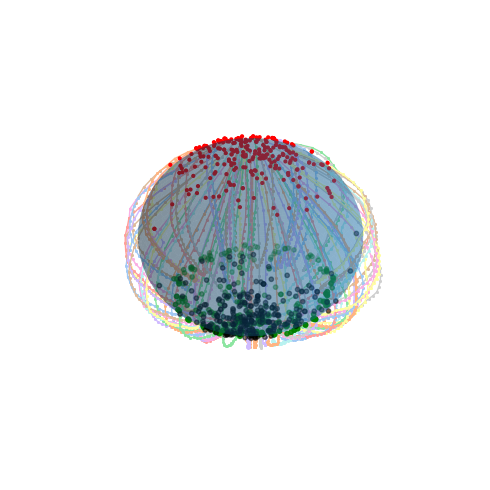

cost 3.698584


100%|██████████████████████████████████████████████████▉| 70000/70001 [12:03<00:00, 96.75it/s, pot_loss=0.0009622374, cost_loss=1.1692197, g_norm=8.637916, g_norm_potential=0.50383836]

W2 0.0602366


In [6]:
# ds init
potential = Sphere_Potential(r=0.98, sigma=0.3, dim=3)
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
DS_LOG_DIR = f"{LOG_DIR}/shpere3d"
if not os.path.exists(DS_LOG_DIR):
    os.mkdir(DS_LOG_DIR)
def callback(step, training_logs, transport):
    clear_output()
    pi0 = next(potential_data_loader)['src_lin']
    pi1 = next(potential_data_loader)['tgt_lin']

    cost, trajs = transport(pi0)

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.grid(False)
    ax.axis('off')
    ids = jax.random.randint(GLOBAL_KEY, 250, 0, trajs[0].x.shape[0])
    ax.scatter(pi0[ids, 0], pi0[ids, 1], pi0[ids, 2], c='red', alpha=1, s=4, zorder=1)

    theta = np.linspace(0, 2 * np.pi, 100)
    phi = np.linspace(0, np.pi, 50)
    theta, phi = np.meshgrid(theta, phi)
    r=0.98
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    ax.plot_surface(x, y, z, alpha=0.3)

    draw_trajs_3d(trajs=jnp.stack([traj.x for traj in trajs])[:, ids[:100]], ax=ax)

    ax.scatter(pi1[ids ,0], pi1[ids, 1], pi1[ids, 2], c='black', alpha=0.5, s=10)
    ax.scatter(trajs[-1].x[ids, 0], trajs[-1].x[ids, 1], trajs[-1].x[ids, 2], c='green', s=10)

    fig.tight_layout()
    fig.savefig(f"{DS_LOG_DIR}/img_{step}.pdf", bbox_inches='tight')
    plt.show()

    sample = next(test_data_loader)
    pi0, pi1 = sample['src_lin'], sample['tgt_lin']
    cost, trajs = transport(pi0) 
    pred = trajs[-1].x
    print("cost", cost)
    print("W2", sinkhorn_loss(pred, pi1))

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
opt = optax.adam(learning_rate=1e-4, b2=0.99)

# method init
noc = HOTA(
    input_dim=3, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=0.4, 
    acc_weight=0.0,
    potential_weight=-5,
    pretrain_steps=1000,
    flow=LagrangianFlow(sigma=0.01, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)